In [25]:
import numpy as np
import pandas as pd

In [26]:
df = pd.read_csv('diminos_data.csv')
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [27]:
df.isnull().sum()
# Remarks no missing values

order_id              0
order_placed_at       0
order_delivered_at    0
dtype: int64

In [28]:
df.duplicated().sum()
# No duplicates

np.int64(0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [30]:
df.columns

Index(['order_id', 'order_placed_at', 'order_delivered_at'], dtype='object')

In [31]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])

In [32]:
df['order_placed_at']

0       2023-03-01 00:00:59
1       2023-03-01 00:03:59
2       2023-03-01 00:07:22
3       2023-03-01 00:07:47
4       2023-03-01 00:09:03
                ...        
14995   2023-03-27 23:37:05
14996   2023-03-27 23:47:38
14997   2023-03-27 23:50:16
14998   2023-03-27 23:52:44
14999   2023-03-27 23:58:20
Name: order_placed_at, Length: 15000, dtype: datetime64[ns]

In [33]:
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])
df['order_delivered_at']

0       2023-03-01 00:18:07.443132
1       2023-03-01 00:19:34.925241
2       2023-03-01 00:22:28.291385
3       2023-03-01 00:46:19.019399
4       2023-03-01 00:25:13.619056
                   ...            
14995   2023-03-27 23:52:37.409378
14996   2023-03-28 00:04:22.672912
14997   2023-03-28 00:05:40.676238
14998   2023-03-28 00:08:41.810358
14999   2023-03-28 00:13:42.499311
Name: order_delivered_at, Length: 15000, dtype: datetime64[ns]

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   order_placed_at     15000 non-null  datetime64[ns]
 2   order_delivered_at  15000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 351.7 KB


In [35]:
df['delivery_time'] = df['order_delivered_at'] - df['order_placed_at']
df['delivery_time']

0       0 days 00:17:08.443132
1       0 days 00:15:35.925241
2       0 days 00:15:06.291385
3       0 days 00:38:32.019399
4       0 days 00:16:10.619056
                 ...          
14995   0 days 00:15:32.409378
14996   0 days 00:16:44.672912
14997   0 days 00:15:24.676238
14998   0 days 00:15:57.810358
14999   0 days 00:15:22.499311
Name: delivery_time, Length: 15000, dtype: timedelta64[ns]

In [36]:
# minutes
df['delivery_time'] = df['delivery_time'].dt.total_seconds() / 60
df['delivery_time'].describe()

count    15000.000000
mean        20.499389
std         96.160362
min         15.000010
25%         15.274826
50%         15.797986
75%         17.279661
max       7299.831375
Name: delivery_time, dtype: float64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

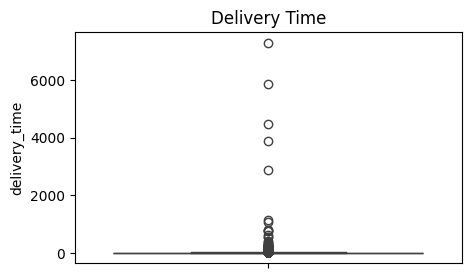

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(df['delivery_time'])
plt.title('Delivery Time')
plt.show()
# contains extreme outliers

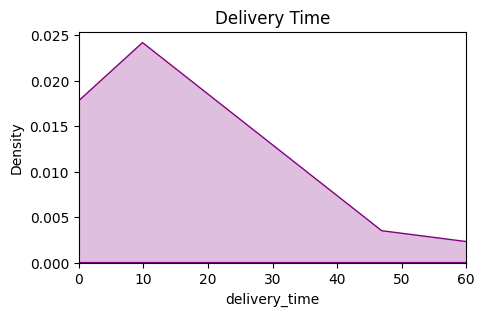

In [39]:
plt.figure(figsize=(5,3))
sns.kdeplot(df['delivery_time'], fill=True, color='purple')
plt.xlim(0,60) # Density estimation for 0mins to 60mins
plt.title('Delivery Time')
plt.show()

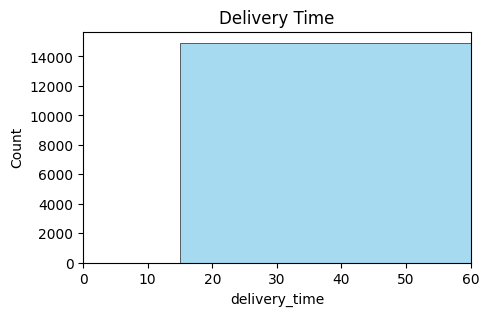

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['delivery_time'], bins=60, color='skyblue')
plt.xlim(0,60) # for 0mins to 60mins
plt.title('Delivery Time')
plt.show()

In [53]:
# outliers
q1 = df['delivery_time'].quantile(0.25)
q3 = df['delivery_time'].quantile(0.75)
iqr = q3-q1
lb = q1 - 1.5*iqr # lower bound
ub = q3 + 1.5*iqr # upper bound
iqr, lb, ub

(np.float64(2.0048349083333363),
 np.float64(12.267573633333328),
 np.float64(20.286913266666673))

In [55]:
df_wo = df[(df['delivery_time'] >= lb) & (df['delivery_time'] <= ub)].reset_index(drop = True) # df after filtering outliers
df_wo.head()

,order_id,order_placed_at,order_delivered_at,delivery_time
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856
3,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984
4,1523116,2023-03-01 00:09:44,2023-03-01 00:25:17.088349,15.551472


In [57]:
df_wo.shape

(13266, 4)

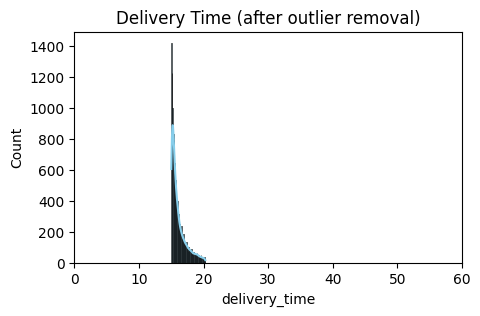

In [105]:
plt.figure(figsize=(5,3))
sns.histplot(df_wo['delivery_time'], bins=60, color='skyblue', kde = True)
plt.xlim(0,60) # for 0mins to 60mins
plt.title('Delivery Time (after outlier removal)')
plt.show()

In [ ]:
p95 = df['delivery_time'].quantile(0.95)
p95 #95th per. dt.
p95, p95 < 31 # so business rqrmnt. satisified

(np.float64(27.261043996666658), np.True_)

In [62]:
def del_category(dt):
    if dt <= 15:
        return "VERY FAST"
    elif dt <= 31:
        return "IN TIME"
    else:
        return "LATE"

df['delivery_category'] = df['delivery_time'].apply(del_category)
df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time,delivery_category
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719,IN TIME
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754,IN TIME
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856,IN TIME
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657,LATE
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984,IN TIME


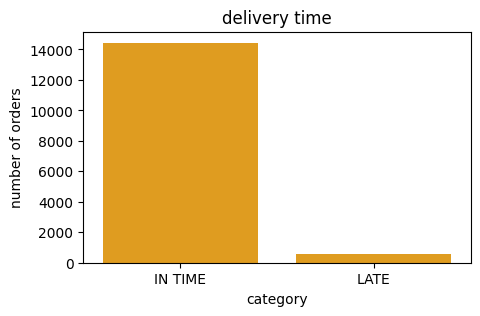

In [106]:
plt.figure(figsize=(5,3))
counts = df.groupby('delivery_category')['delivery_category'].count()
sns.barplot(x=counts.index, y=counts.values, color='orange')
plt.title('delivery time')
plt.ylabel('number of orders')
plt.xlabel('category')
plt.show()
# as we can see, most of the orders are delivered in time

In [70]:
# delivery analysis
df['hour'] = df['order_placed_at'].dt.hour
df['dow'] = df['order_placed_at'].dt.day_name() # day of week
df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time,delivery_category,hour,dow
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719,IN TIME,0,Wednesday
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754,IN TIME,0,Wednesday
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856,IN TIME,0,Wednesday
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657,LATE,0,Wednesday
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984,IN TIME,0,Wednesday


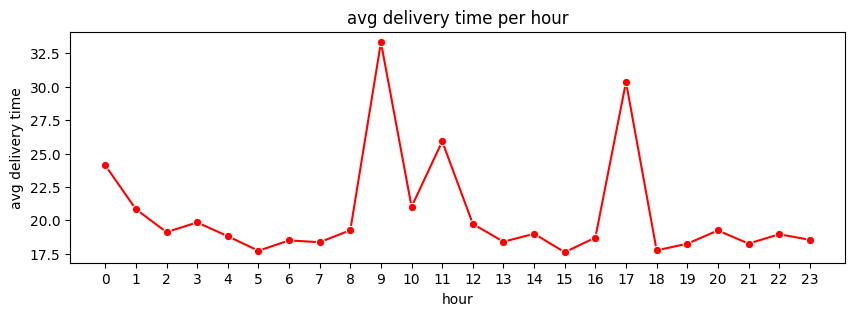

In [78]:
h_avg = df.groupby('hour')['delivery_time'].mean() # average delivery time grouped by hour
plt.figure(figsize=(10,3))
sns.lineplot(x=h_avg.index, y=h_avg.values, color='red', marker = 'o')
plt.title('avg delivery time per hour')
plt.xlabel('hour')
plt.ylabel('avg delivery time')
plt.xticks(range(0,24))
plt.show()

In [79]:
# Therefore, del time is the highest when the order placed between 8-10 hour

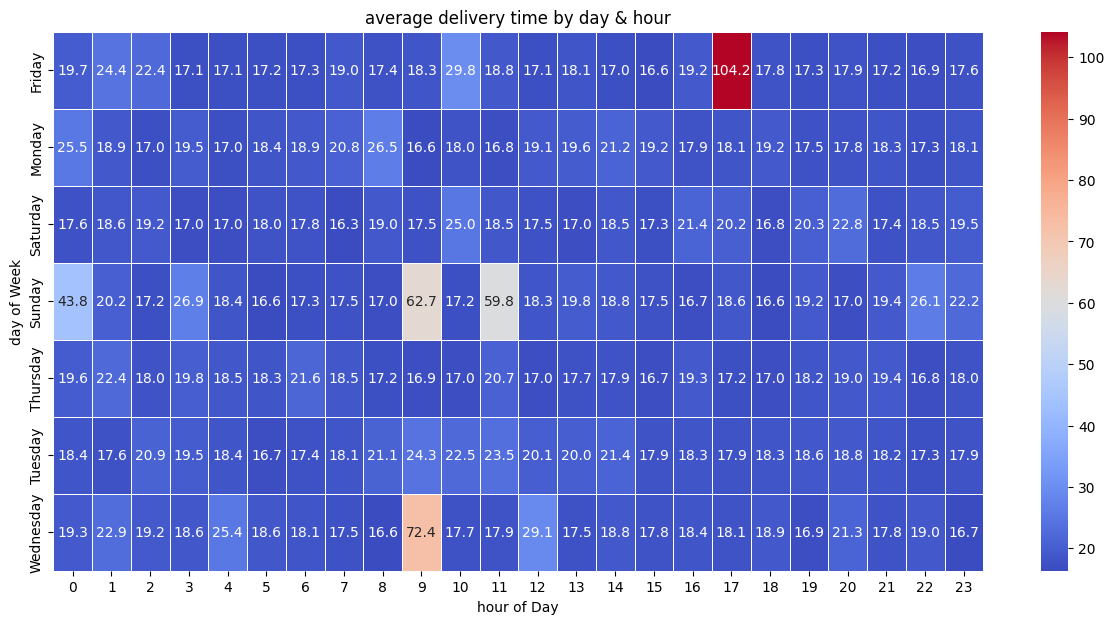

In [100]:
dow_hr = df.groupby(['dow', 'hour'])['delivery_time'].mean()
data = dow_hr.unstack()
plt.figure(figsize=(15,7))
sns.heatmap(data, cmap='coolwarm', linewidths=0.5, annot=True, fmt=".1f")
plt.title('average delivery time by day & hour')
plt.xlabel('hour of Day')
plt.ylabel('day of Week')
plt.show()
# Friday at 17th hour are extreme outliers

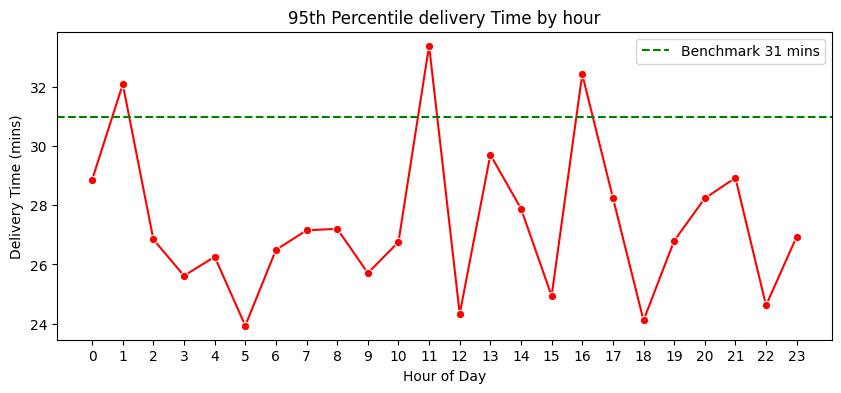

In [101]:
# 95th perc. / hour
hour_p95 = df.groupby('hour')['delivery_time'].quantile(0.95)
plt.figure(figsize=(10,4))
sns.lineplot(x=hour_p95.index, y=hour_p95.values, marker='o', color='red')
plt.axhline(31, color='green', linestyle='--', label='Benchmark 31 mins')
plt.title('95th Percentile delivery Time by hour')
plt.xlabel('Hour of Day')
plt.ylabel('Delivery Time (mins)')
plt.xticks(range(0,24))
plt.legend()
plt.show()

In [88]:
hour_p95

hour
0     28.866990
1     32.104821
2     26.845717
3     25.617373
4     26.259762
5     23.924907
6     26.493076
7     27.154475
8     27.207707
9     25.709020
10    26.759252
11    33.407016
12    24.327900
13    29.714826
14    27.891228
15    24.933851
16    32.438371
17    28.260021
18    24.104592
19    26.801610
20    28.237978
21    28.932870
22    24.611743
23    26.943743
Name: delivery_time, dtype: float64

In [89]:
risk_hours = hour_p95[hour_p95 > 31]
risk_hours

hour
1     32.104821
11    33.407016
16    32.438371
Name: delivery_time, dtype: float64

In [91]:
import warnings
warnings.filterwarnings('ignore')

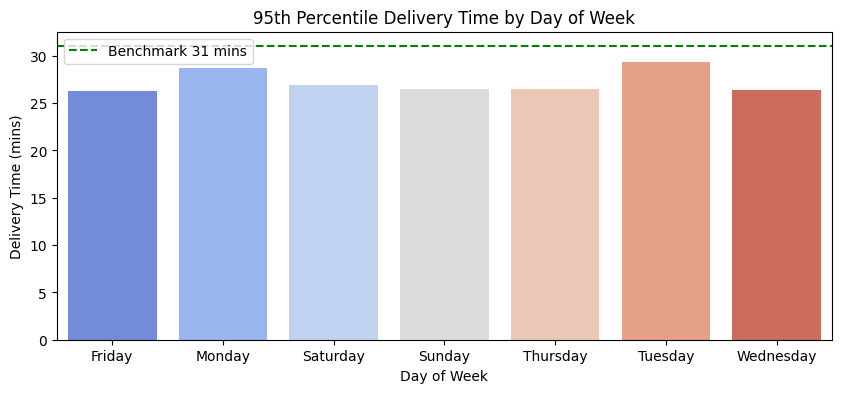

In [93]:
# 95th perc. / dow
dow_p95 = df.groupby('dow')['delivery_time'].quantile(0.95)
plt.figure(figsize=(10,4))
sns.barplot(x=dow_p95.index, y=dow_p95.values, palette='coolwarm')
plt.axhline(31, color='green', linestyle='--', label='Benchmark 31 mins')
plt.title('95th Percentile Delivery Time by Day of Week')
plt.ylabel('Delivery Time (mins)')
plt.xlabel('Day of Week')
plt.legend()
plt.show()

In [ ]:
risk_days = dow_p95[dow_p95 > 31]
risk_days # No days are particularly risky

Series([], Name: delivery_time, dtype: float64)

In [103]:
late_orders = df[df['delivery_time'] > 31]
late_counts = late_orders.groupby(['dow','hour'])['delivery_time'].count().reset_index(name='Late_Count')
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
late_counts['dow'] = pd.Categorical(late_counts['dow'], categories=dow_order, ordered=True)

late_orders

,order_id,order_placed_at,order_delivered_at,delivery_time,delivery_category,hour,dow
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657,LATE,0,Wednesday
24,1523135,2023-03-01 01:11:53,2023-03-01 05:07:54.563978,236.026066,LATE,1,Wednesday
47,1523158,2023-03-01 01:57:16,2023-03-01 02:30:19.851911,33.064199,LATE,1,Wednesday
117,1523228,2023-03-01 04:59:04,2023-03-01 18:06:52.046891,787.800782,LATE,4,Wednesday
174,1523285,2023-03-01 07:22:11,2023-03-01 08:12:51.906470,50.681774,LATE,7,Wednesday
...,...,...,...,...,...,...,...
14841,1537952,2023-03-27 16:42:37,2023-03-27 17:43:13.294744,60.604912,LATE,16,Monday
14855,1537966,2023-03-27 17:16:14,2023-03-27 17:49:07.476278,32.891271,LATE,17,Monday
14899,1538010,2023-03-27 19:31:50,2023-03-27 20:08:26.866824,36.614447,LATE,19,Monday
14939,1538050,2023-03-27 21:17:20,2023-03-27 21:54:03.464048,36.724401,LATE,21,Monday


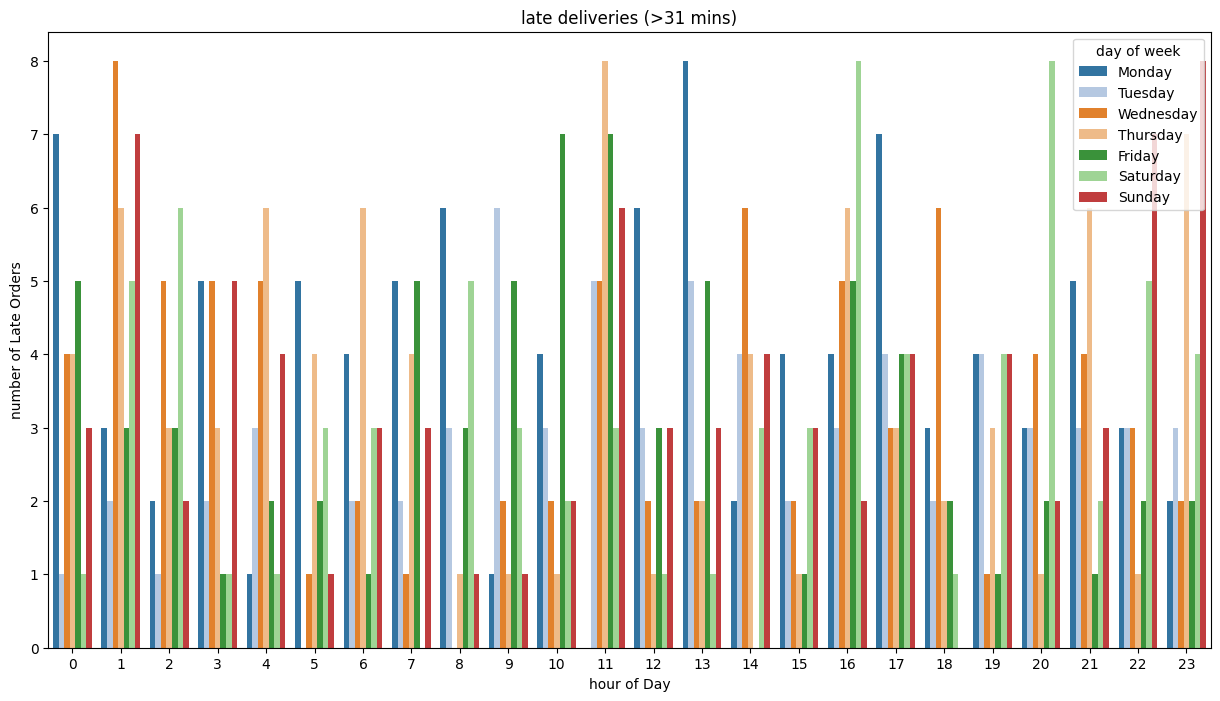

In [104]:
plt.figure(figsize=(15,8))
sns.barplot(x='hour', y='Late_Count', hue='dow', data=late_counts, palette='tab20')
plt.title('late deliveries (>31 mins)')
plt.ylabel('number of Late Orders')
plt.xlabel('hour of Day')
plt.legend(title='day of week')
plt.show()